# Lab - Data-Centric Evaluation of ML Models

This lab is intended to accompany the lecture on Data-Centric Evaluation of ML Models. In this lab, you are given a training dataset and your goal is to improve the dataset in order to boost the accuracy of a fixed classification model on a given (fixed) test dataset. Reviewing the lecture notes will be helpful to get some ideas.

You can get all the dependencies you need for this notebook by running:

In [ ]:
!pip install cleanlab matplotlib

In [99]:
import pandas as pd
import numpy as np

import sklearn
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
SEED = 123
np.random.seed(SEED)  # for reproducibility

# Load dataset

The data come from a 3-class classification task where the goal is to predict `y` based on features `x1`, ..., `x5`.
We convert the data to a numpy array format.

In [80]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [81]:
df.head()

,x0,x1,x2,x3,x4,x5,y
0,-0.333489,-0.770208,-2.697486,-0.628563,-1.277720,100.0,2
1,-0.787124,1.230800,1.415472,-0.805927,0.175115,100.0,1
2,0.781197,-0.856227,2.138879,2.495417,0.868192,100.0,1
3,1.895093,-0.885939,1.946352,-2.082747,0.064914,100.0,1
4,0.689091,-5.091299,-2.218682,0.330767,3.012755,100.0,2


In [82]:
df_test.head()

,x0,x1,x2,x3,x4,x5,y
0,2.337701,-0.681121,1.883774,0.949812,-0.311507,-100.0,1
1,1.101249,-2.032961,0.344490,0.724925,1.355534,-100.0,2
2,1.791349,-2.808856,-1.409471,0.552069,0.433901,100.0,2
3,2.082599,0.811498,0.906920,-0.749352,1.974424,-100.0,2
4,1.214627,-0.448392,1.812024,0.429543,0.396450,-100.0,1


In [83]:
y = df["y"].values
df_X = df.drop(columns=["y"])
X = df_X.values

y_test = df_test["y"].values
df_X_test = df_test.drop(columns=["y"])
X_test = df_X_test.values

print(X)
print(y)

[[  -0.33348927   -0.7702077    -2.69748604   -0.62856274   -1.27772042
   100.        ]
 [  -0.7871239     1.23080016    1.41547226   -0.8059272     0.1751147
   100.        ]
 [   0.78119711   -0.85622725    2.13887864    2.49541712    0.86819164
   100.        ]
 ...
 [   1.19101444   -1.72465036   -1.17854745   -1.54881816   -1.51740071
  -100.        ]
 [  -2.03358571   -0.23977122    1.21509471    0.86023614    0.69816843
   100.        ]
 [   0.15125519   -1.21711969    2.77498591    0.7090941     0.89159205
  -100.        ]]
[2 1 1 ... 2 1 1]


Here's a simple plot of the first two features, colored by class. Visualizing the dataset may be helpful to you in this assignment, but can be tricky with 6-dimensional features!

<Axes: xlabel='x4', ylabel='x1'>

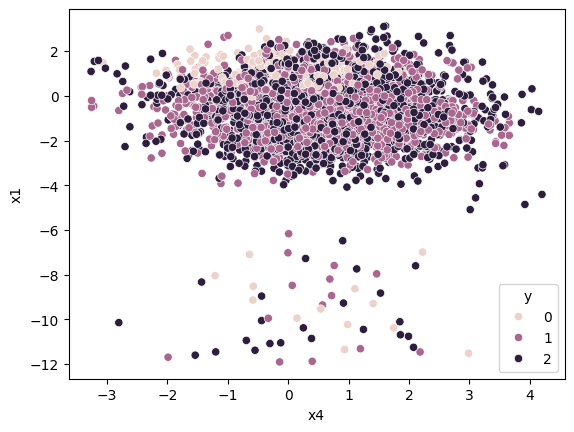

In [103]:
sns.scatterplot(df, x="x4", y="x1", hue="y")

# Improve ML Model via data-centric techniques

We train a simple neural network model (Multi-Layer Perceptron classifier) and evaluate it on the given test set. 
Note that the evaluation metric used is `balanced_accuracy`. This is the accuracy amongst all examples in a given class, averaged over all classes, which better represents performance on minority classes.

You should never change the test data labels `y_test` in this lab, nor the neural network model. You may change the training data `X`, `y` as you see fit, and update `X_test` accordingly so your model is able to make predictions on it.

In [76]:
def train_evaluate_model(X, y, X_test, y_test):
    model = MLPClassifier(early_stopping=True, random_state=SEED)
    model.fit(X, y)
    predictions = model.predict(X_test)
    acc = balanced_accuracy_score(y_true=y_test, y_pred=predictions)
    print(f"Balanced accuracy = {acc}")
    return predictions

def f1_score(label, predictions, y_test):
    #print(label, predictions, y_test)
    correct = np.sum((predictions == label) * (y_test == label))
    recall = correct / np.sum(y_test == label)
    precision = correct / np.sum(predictions == label)
    f1 = float(2 * recall * precision / (recall + precision))
    print("F1 wrt. class", label, "is", f1)
    return f1
    
    

A baseline version of the model is trained on the original given data:

In [95]:
predictions = train_evaluate_model(X, y, X_test, y_test)
f1_0 = f1_score(0, predictions, y_test)
f1_1 = f1_score(1, predictions, y_test)
f1_2 = f1_score(2, predictions, y_test)

# Number of predictions of class 0
f"Number of predictions of class 0: { int(np.sum(predictions == 0))}"

Balanced accuracy = 0.5759397707696671
F1 wrt. class 0 is 0.023121387283236997
F1 wrt. class 1 is 0.8322359757703451
F1 wrt. class 2 is 0.8452316076294278


'Number of predictions of class 0: 2'

# Exercise

Your goal is to produce a version of this same model that has much better test accuracy! 
You should accomplish this by changing `X` and `y` as you see fit. Consider various ideas presented in the lecture and look through the data yourself to see if other ideas come to mind! Greater than 80% test accuracy is achievable without modifying the model at all. If you choose to drop/add features to `X` or renormalize some values, then you'll want to apply these operations to `X_test` as well.

In [ ]:
# First, let's investigate if there is a lot of correlation
df.corr()

# Doesn't look like it

,x0,x1,x2,x3,x4,x5,y
x0,1.000000,0.018890,0.003268,0.032845,-0.002186,0.009385,0.031221
x1,0.018890,1.000000,-0.038285,-0.005338,-0.051849,-0.018997,-0.082800
x2,0.003268,-0.038285,1.000000,0.047981,0.051323,0.018016,-0.642782
x3,0.032845,-0.005338,0.047981,1.000000,0.030441,0.013663,-0.011282
x4,-0.002186,-0.051849,0.051323,0.030441,1.000000,0.014683,0.073084
x5,0.009385,-0.018997,0.018016,0.013663,0.014683,1.000000,0.006871
y,0.031221,-0.082800,-0.642782,-0.011282,0.073084,0.006871,1.000000


In [107]:
## Poor F1 score distributional shift; few 0s in the training data
## Or just poor learning of class 0 from the training data

df[df["y"] == 0]

,x0,x1,x2,x3,x4,x5,y
11,-1.262347,1.638896,1.962362,-0.960920,-0.617275,100.0,0
15,-0.446627,1.431052,1.864645,-0.202909,0.159902,-100.0,0
18,-0.894137,0.996667,1.224930,0.935192,-1.387181,100.0,0
22,1.181139,1.541684,1.562669,1.641136,-1.860531,-100.0,0
46,-0.393142,0.814252,1.510436,1.036417,1.164309,-100.0,0
...,...,...,...,...,...,...,...
3722,0.698648,-0.014184,0.678556,-2.316617,-0.602071,-100.0,0
3734,2.148178,1.552274,1.518976,0.368219,1.190323,100.0,0
3736,-0.163950,0.855642,1.492628,-1.410966,0.578025,-100.0,0
3790,1.357566,1.562047,1.238480,-0.090169,-0.484302,-100.0,0


In [108]:
df[df["y"] == 1]

,x0,x1,x2,x3,x4,x5,y
1,-0.787124,1.230800,1.415472,-0.805927,0.175115,100.0,1
2,0.781197,-0.856227,2.138879,2.495417,0.868192,100.0,1
3,1.895093,-0.885939,1.946352,-2.082747,0.064914,100.0,1
5,0.824279,-0.182799,1.449817,1.519336,0.928320,-100.0,1
7,-1.924815,-0.634051,1.935553,0.919129,1.344579,100.0,1
...,...,...,...,...,...,...,...
3862,0.739115,-1.419598,0.928048,-0.107993,-0.584282,-100.0,1
3865,-1.879916,-1.673453,0.836484,0.464720,1.694618,-100.0,1
3866,-0.980495,-2.437797,3.593273,1.475076,0.827983,-100.0,1
3868,-2.033586,-0.239771,1.215095,0.860236,0.698168,100.0,1


Clear imbalance: class 0 has roughly 200 examples, while the other two have roughly 2000 examples. Let's subsample the two other classes and see what happens

In [ ]:
SUBSAMPLE = len(df[df["y"] == 0])
df_prime = pd.concat([df[df["y"] == 0], df[df["y"] == 1].sample(SUBSAMPLE), df[df["y"] == 2].sample(SUBSAMPLE)])
y_prime = df_prime["y"].values
df_prime_X = df_prime.drop(columns=["y"])
X_prime = df_prime_X.values

predictions = train_evaluate_model(X_prime, y_prime, X_test, y_test)


Balanced accuracy = 0.7413482287605273
F1 wrt. class 0 is 0.2506142506142506
F1 wrt. class 1 is 0.6800394607037159
F1 wrt. class 2 is 0.8241563055062168


Substantially improved performance! 57% to 73%. The values of the last covariate look kinda large too. Maybe we want to normalize the data.

In [ ]:
SUBSAMPLE = len(df[df["y"] == 0])
df_prime = pd.concat([df[df["y"] == 0], df[df["y"] == 1].sample(SUBSAMPLE), df[df["y"] == 2].sample(SUBSAMPLE)])
y_prime = df_prime["y"].values
df_prime_X = df_prime.drop(columns=["y"])
X_prime = df_prime_X.values
xmean, xstd = np.std(X_prime, axis=0), np.std(X_prime, axis=0)
print("Means and st deviations", xmean, xstd)

X_prime = (X_prime - xmean) / xstd
X_test_prime = (X_test - xmean) / xstd

predictions = train_evaluate_model(X_prime, y_prime, X_test_prime, y_test)

Means and st deviations [ 1.02378574  2.01563731  1.36738351  1.09889729  1.12805916 99.99368747] [ 1.02378574  2.01563731  1.36738351  1.09889729  1.12805916 99.99368747]
Balanced accuracy = 0.7069300294372636


Well, that didn't help. Let's check if there are duplicates in the data

In [168]:
df.drop_duplicates("x2")

,x0,x1,x2,x3,x4,x5,y
0,-0.333489,-0.770208,-2.697486,-0.628563,-1.277720,100.0,2
1,-0.787124,1.230800,1.415472,-0.805927,0.175115,100.0,1
2,0.781197,-0.856227,2.138879,2.495417,0.868192,100.0,1
3,1.895093,-0.885939,1.946352,-2.082747,0.064914,100.0,1
4,0.689091,-5.091299,-2.218682,0.330767,3.012755,100.0,2
...,...,...,...,...,...,...,...
3865,-1.879916,-1.673453,0.836484,0.464720,1.694618,-100.0,1
3866,-0.980495,-2.437797,3.593273,1.475076,0.827983,-100.0,1
3867,1.191014,-1.724650,-1.178547,-1.548818,-1.517401,-100.0,2
3868,-2.033586,-0.239771,1.215095,0.860236,0.698168,100.0,1


Basically no duplicates either. Let's try the other way, upsampling the minority class:

In [326]:
UPSAMPLE = len(df[df["y"] == 2])
df_prime = pd.concat([df[df["y"] == 0].sample(UPSAMPLE, replace=True), df[df["y"] == 1], df[df["y"] == 2]])
y_prime = df_prime["y"].values
df_prime_X = df_prime.drop(columns=["y"])
X_prime = df_prime_X.values

predictions = train_evaluate_model(X_prime, y_prime, X_test, y_test)


Balanced accuracy = 0.8027039987516451


In [307]:
X_prime.shape
class1and2 = len(df[df["y"] == 1]) + len(df[df["y"] == 2])
jitter = np.random.randn(UPSAMPLE, 6) * 0.01
zeros = np.zeros((class1and2, 6))
addition = np.concat([jitter, zeros])

predictions = train_evaluate_model(X_prime + addition, y_prime, X_test, y_test)


Balanced accuracy = 0.8062750067746766


Adding a little bit of jitter to the copies of the same inputs squeezed out a little more accuracy. In all fairness, the initialization noise does render the difference negligible, but the jittered data is more stable across runs too.

### Results summary

- There was no correlation between the features
- Normalizing the features did not affect the performance
- Class 0 was underrepresented in the training set
    - Undersampling the other classes improved performance to 0.74
    - Oversampling class 0 improved performance to 0.80+
- Adding jitter to the copies of the oversampled features might make the algorithm stable